# Анализ результатов АБ-теста

In [23]:
import statsmodels
import scipy as sc
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.graphics.regressionplots import plot_leverage_resid2
import matplotlib.pyplot as plt

In [15]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


Описание  данных:

userID:  уникальный идентификатор пользователя

browser:  браузер, который использовал userID

slot: в каком статусе пользователь участвовал в исследовании (exp = видел измененную страницу, control  = видел неизменную страницу)

n_clicks: количество кликов, которые пользователь совершил за n_queries

n_queries: количество запросов, который совершил userID, пользуясь браузером browser

n_nonclk_queries: количество запросов пользователя, в которых  им не было совершено ни одного клика

Обращаем ваше внимание, что не все люди используют только один браузер, поэтому в столбце userID есть повторяющиеся идентификаторы. В предлагаемых данных  уникальным является сочетание userID и browser.

In [4]:
data = pd.read_csv('ab_browser_test.csv', sep = ',', header = 0)
data

,userID,browser,slot,n_clicks,n_queries,n_nonclk_queries
0,1,Browser #2,exp,23,32,19
1,3,Browser #4,exp,3,4,2
2,5,Browser #4,exp,29,35,16
3,6,Browser #4,control,12,6,0
4,7,Browser #4,exp,54,68,30
...,...,...,...,...,...,...
566129,603133,Browser #14,control,1,2,1
566130,603134,Browser #2,exp,4,2,0
566131,603135,Browser #4,control,0,1,1
566132,603136,Browser #4,control,2,3,1


#### 1

Основная метрика, на которой мы сосредоточимся в этой работе, — это количество пользовательских кликов на web-странице в зависимости от тестируемого изменения этой страницы. 

Посчитайте, насколько в группе exp больше пользовательских кликов по сравнению с группой control в процентах от числа кликов в контрольной группе.

Полученный процент округлите  до третьего знака после точки. 

In [5]:
data_exp = data[data['slot'] == 'exp']
data_control = data[data['slot'] == 'control']

In [6]:
x = (data_exp['n_clicks'].sum() - data_control['n_clicks'].sum()) * 100 / data_control['n_clicks'].sum()
round(x, 3)

1.614

#### 2

Давайте попробуем посмотреть более внимательно на разницу между двумя группами (control и exp) относительно количества пользовательских кликов.

Для этого постройте с помощью бутстрепа 95% доверительный интервал для средних значений и медиан количества кликов в каждой из двух групп. Отметьте все верные утверждения. 

In [7]:
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

In [8]:
def stat_intervals(stat, alpha):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [9]:
X0 = data_exp.n_clicks.values
X1 = data_control.n_clicks.values

In [10]:
# доверительный интервал для средних значений
np.random.seed(0)

X0_mean = (map(np.mean, get_bootstrap_samples(X0, 1000)))
X1_mean = (map(np.mean, get_bootstrap_samples(X1, 1000)))
diff_means = map(lambda x: x[0] - x[1], zip(X0_mean, X1_mean))

stat_intervals(list(diff_means), 0.05)

array([0.19172563, 0.40475697])

In [11]:
# доверительный интервал для медиан
np.random.seed(0)

X0_median = (map(np.median, get_bootstrap_samples(X0, 1000)))
X1_median = (map(np.median, get_bootstrap_samples(X1, 1000)))
diff_median = map(lambda x: x[0] - x[1], zip(X0_median, X1_median))

stat_intervals(list(diff_median), 0.05)

array([1., 1.])

95% доверительный интервал для разности средних не содержит ноль, похоже, средние отличаются статистически значимо.

95% доверительный интервал для разности медиан не содержит ноль, похоже, средние отличаются статистически значимо.

#### 4

Поскольку мы не знаем истинного распределения генеральной совокупности, мы можем применить бутстреп, чтобы понять, как распределены среднее значение и выборочная дисперсия. Для этого 

1. Получите из данных n_boot_samples  псевдовыборок. 

2. По каждой из этих выборок посчитайте среднее и сумму квадратов отклонения от выборочного среднего (control_boot_chi_squared) 

3. Для получившегося вектора средних значений из n_boot_samples постройте q-q plot с помощью scipy.stats.probplot для нормального распределения

4. Для получившегося вектора  сумм квадратов отклонения от выборочного среднего постройте  qq-plot с помощью scipy.stats.probplot  для хи-квадрат распределения

#### (в этом задании накосячил, решение и графики неверные)

In [52]:
np.random.seed(0)
n_boot_samples = 50
control_boot_mean = list(map(statistics.mean, get_bootstrap_samples(X1, n_boot_samples)))
control_boot_chi_squared = list(map(statistics.stdev, get_bootstrap_samples(X1, n_boot_samples)))

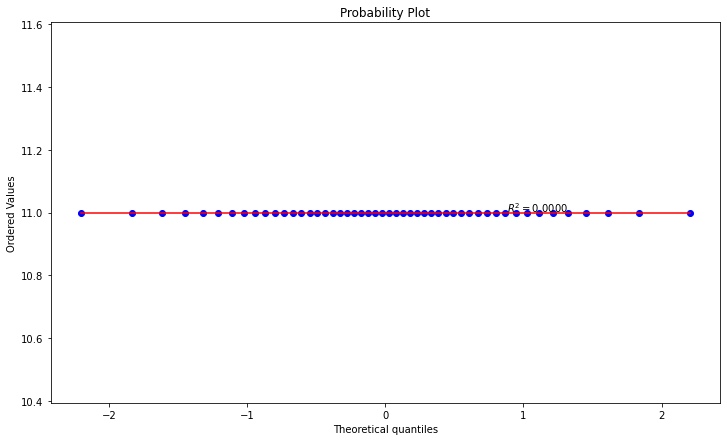

In [60]:
plt.figure(figsize(12,7))
sc.stats.probplot(control_boot_mean, dist="norm", plot=pylab, rvalue=True)
pylab.show()

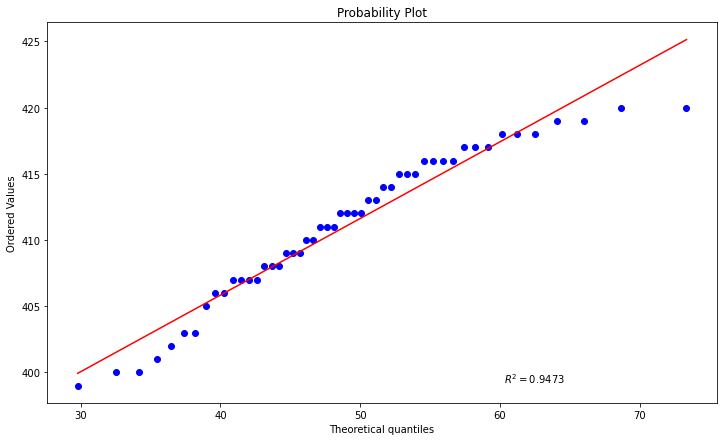

In [59]:
plt.figure(figsize(12,7))
scipy.stats.probplot(control_boot_chi_squared, dist="chi2", sparams=(len(control_boot_chi_squared)-1), plot=pylab, rvalue=True)
pylab.show()

R2 для выборочной суммы квадратов отклонения от выборочной суммы получился больше, чем 0.99

R2 для выборочного среднего получился больше, чем 0.99

#### 5

Одним из возможных аналогов t-критерия, которым можно воспрользоваться, является тест Манна-Уитни. На достаточно обширном классе распределений он является асимптотически более эффективным, чем t-критерий, и при этом не требует параметрических предположений о характере распределения.

Разделите выборку на две части, соответствующие control  и exp группам. Преобразуйте данные к виду, чтобы каждому пользователю  соответствовало суммарное значение его кликов. С помощью критерия Манна-Уитни проверьте гипотезу о равенстве средних. Что можно сказать о получившемся значении достигаемого уровня значимости ? Выберите все правильные ответы

In [67]:
data_control_sum = data_control.groupby(['userID']).sum()
data_exp_sum = data_exp.groupby(['userID']).sum()

In [70]:
sc.stats.mannwhitneyu(data_control_sum['n_clicks'], data_exp_sum['n_clicks'])

MannwhitneyuResult(statistic=38901259929.0, pvalue=4.3471471887604393e-75)

Получившееся значение достигаемого уровня значимости свидетельствует о статистической значимости отличий между двумя выборками.

#### 6

Проверьте, для какого из браузеров наиболее сильно выражено отличие между количеством кликов в контрольной и экспериментальной группах.

Для этого примените для каждого из срезов (по каждому из уникальных значений столбца browser) критерий Манна-Уитни между control и exp группами и сделайте поправку Холма-Бонферрони на множественную проверку с \alpha=0.05

Какое заключение можно сделать исходя из полученных результатов ?

В качестве ответа введите количество незначимых изменений с точки зрения результатов, полученных после введения коррекции.

In [73]:
data['browser'].unique()

array(['Browser #2', 'Browser #4', 'Browser #14', 'Browser #17',
       'Browser #20', 'Browser #22'], dtype=object)

In [80]:
p_arr = []

for browser in data['browser'].unique():
    stat, p = sc.stats.mannwhitneyu(data_control[data_control['browser'] == browser]['n_clicks'],
                                    data_exp[data_exp['browser'] == browser]['n_clicks'])
    p_arr.append(p)

In [81]:
p_arr

[0.0272438604197241,
 0.40760617658454984,
 0.0,
 0.03740060143010802,
 0.45366656388735377,
 0.2574055152210032]

In [83]:
import statsmodels.stats.multitest as smm
reject, p_corrected, a1, a2 = smm.multipletests(p_arr, 
                                            alpha = 0.05, 
                                            method = 'holm') 

In [84]:
p_corrected

array([0.1362193 , 0.81521235, 0.        , 0.14960241, 0.81521235,
       0.77221655])

In [85]:
reject

array([False, False,  True, False, False, False])

Ответ: 5

#### 7

Для каждого браузера в каждой из двух групп (control  и exp) посчитайте долю запросов, в которых пользователь не кликнул ни разу. Это можно сделать, поделив сумму значений  n_nonclk_queries  на сумму значений  n_queries. Умножив это значение на 100, получим процент некликнутых запросов, который можно легче  проинтерпретировать.

Сходятся ли результаты проведенного Вами анализа с показателем процента некликнутых запросов ? Отметьте все верные утверждения. 

In [97]:
nonclk_control_arr = []

for browser in data['browser'].unique():
    nonclk_control_arr.append(
        len(data_control[(data_control['browser'] == browser) & (data_control['n_clicks'] == 0)]) * 100 /
        len(data_control[data_control['browser'] == browser]))
nonclk_control_arr

[18.09187532486154,
 10.124426481615638,
 32.89980624902568,
 11.208267090620032,
 10.136486645487704,
 11.863557257222416]

In [100]:
nonclk_exp_arr = []

for browser in data['browser'].unique():
    nonclk_exp_arr.append(
        len(data_exp[(data_exp['browser'] == browser) & (data_exp['n_clicks'] == 0)]) * 100 /
        len(data_exp[data_exp['browser'] == browser]))
nonclk_exp_arr

[17.568797320908562,
 9.814208209642748,
 19.194934418815016,
 10.871839045099366,
 9.975784064733329,
 11.923185143500282]

С помощью анализа, проведённого в предыдущем вопросе, мы показали, что тестируемое изменение приводит к статистически значимому отличию только для одного браузера (Browser #14). Для этого браузера, на основе данных о доле некликнутых запросов, заключаем, что тестируемое изменение влияет на пользователей позитивно.